# Exponential Smoothing in State Space Form with `numpyro_forecast`

Exponential smoothing is one of the most widely used forecasting
techniques. In its classical (component) form it is a set of recursive
update equations for a *level*, a *trend*, and a *seasonal* component. A
more powerful way to write the same idea is the **innovations state
space form** (also known as the single source of error, or SSOE, model),
which turns exponential smoothing into a proper generative stochastic
process. The key consequence is that forecast uncertainty is propagated
correctly: the prediction interval widens with the horizon instead of
collapsing to the observation noise.

This notebook ports the blog post [*Exponential Smoothing with NumPyro:
State Space
Form*](https://juanitorduz.github.io/exponential_smoothing_numpyro_ssm/)
(with material from its predecessor [*Notes on Exponential Smoothing
with
NumPyro*](https://juanitorduz.github.io/exponential_smoothing_numpyro/))
into a `numpyro_forecast` example. We show how to write the damped
Holt-Winters model in state space form as a **custom forecasting model**
that plugs into the package’s `HMCForecaster`, forecasting, and
evaluation machinery, and we introduce the JAX `scan` primitive that
rolls the latent state forward.

A practical note on the design: the built-in
`numpyro_forecast.functional.time_series` and `predict` primitives
assume a deterministic mean plus independent per-step Gaussian noise,
which is not how an innovations model behaves. We therefore write the
model body directly against the functional API’s `Horizon` value,
registering the framework’s `"obs"` and `"forecast"` sites ourselves,
while still reusing everything downstream of the model.

## Prepare notebook

In [1]:
import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
import preliz as pz
from jax import random
from numpyro.infer import Predictive

from numpyro_forecast import (
    HMCForecaster,
    eval_coverage,
    eval_crps,
    eval_mae,
    eval_rmse,
    forecasting_model,
)
from numpyro_forecast.functional import Horizon
from numpyro_forecast.typing import Array

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)

%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/preliz/ppls/pymc_io.py:16: UserWarning: PyMC not installed. PyMC related functions will not work.
  warnings.warn("PyMC not installed. PyMC related functions will not work.")
/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/preliz/ppls/agnostic.py:34: UserWarning: PyMC not installed. PyMC related functions will not work.
  warnings.warn("PyMC not installed. PyMC related functions will not work.")

## Generate synthetic data

We use the same synthetic series as the source posts: a seasonal cosine
wave with period $m = 15$, a slow logarithmic trend, and additive
Gaussian noise,

$$y_t = \cos(2 \pi t) + \log(t + 1) + 0.2 \, \varepsilon_t, \qquad \varepsilon_t \sim \text{Normal}(0, 1).$$

This gives us a trend, a clear seasonality, and enough noise to make the
inference interesting. We hold out the last $20\%$ of the series as a
test set.

In [2]:
n_seasons = 15
t = jnp.linspace(0, n_seasons + 1, (n_seasons + 1) * n_seasons)

rng_key, rng_subkey = random.split(rng_key)
y = jnp.cos(2 * jnp.pi * t) + jnp.log(t + 1) + 0.2 * random.normal(rng_subkey, t.shape)

n = y.shape[0]
n_train = int(0.8 * n)

t_train, t_test = t[:n_train], t[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

# The package expects time at axis -2 and the observation dimension at axis -1.
train_data = y_train[:, None]
test_data = y_test[:, None]

# This univariate model has no exogenous regressors, so the covariates only carry
# the horizon length: zeros over the training window and over the full horizon.
covariates_train = jnp.zeros((n_train, 1))
covariates_full = jnp.zeros((n, 1))

future = n - n_train
print(f"total: {n}, train: {n_train}, test (forecast horizon): {future}")

total: 240, train: 192, test (forecast horizon): 48

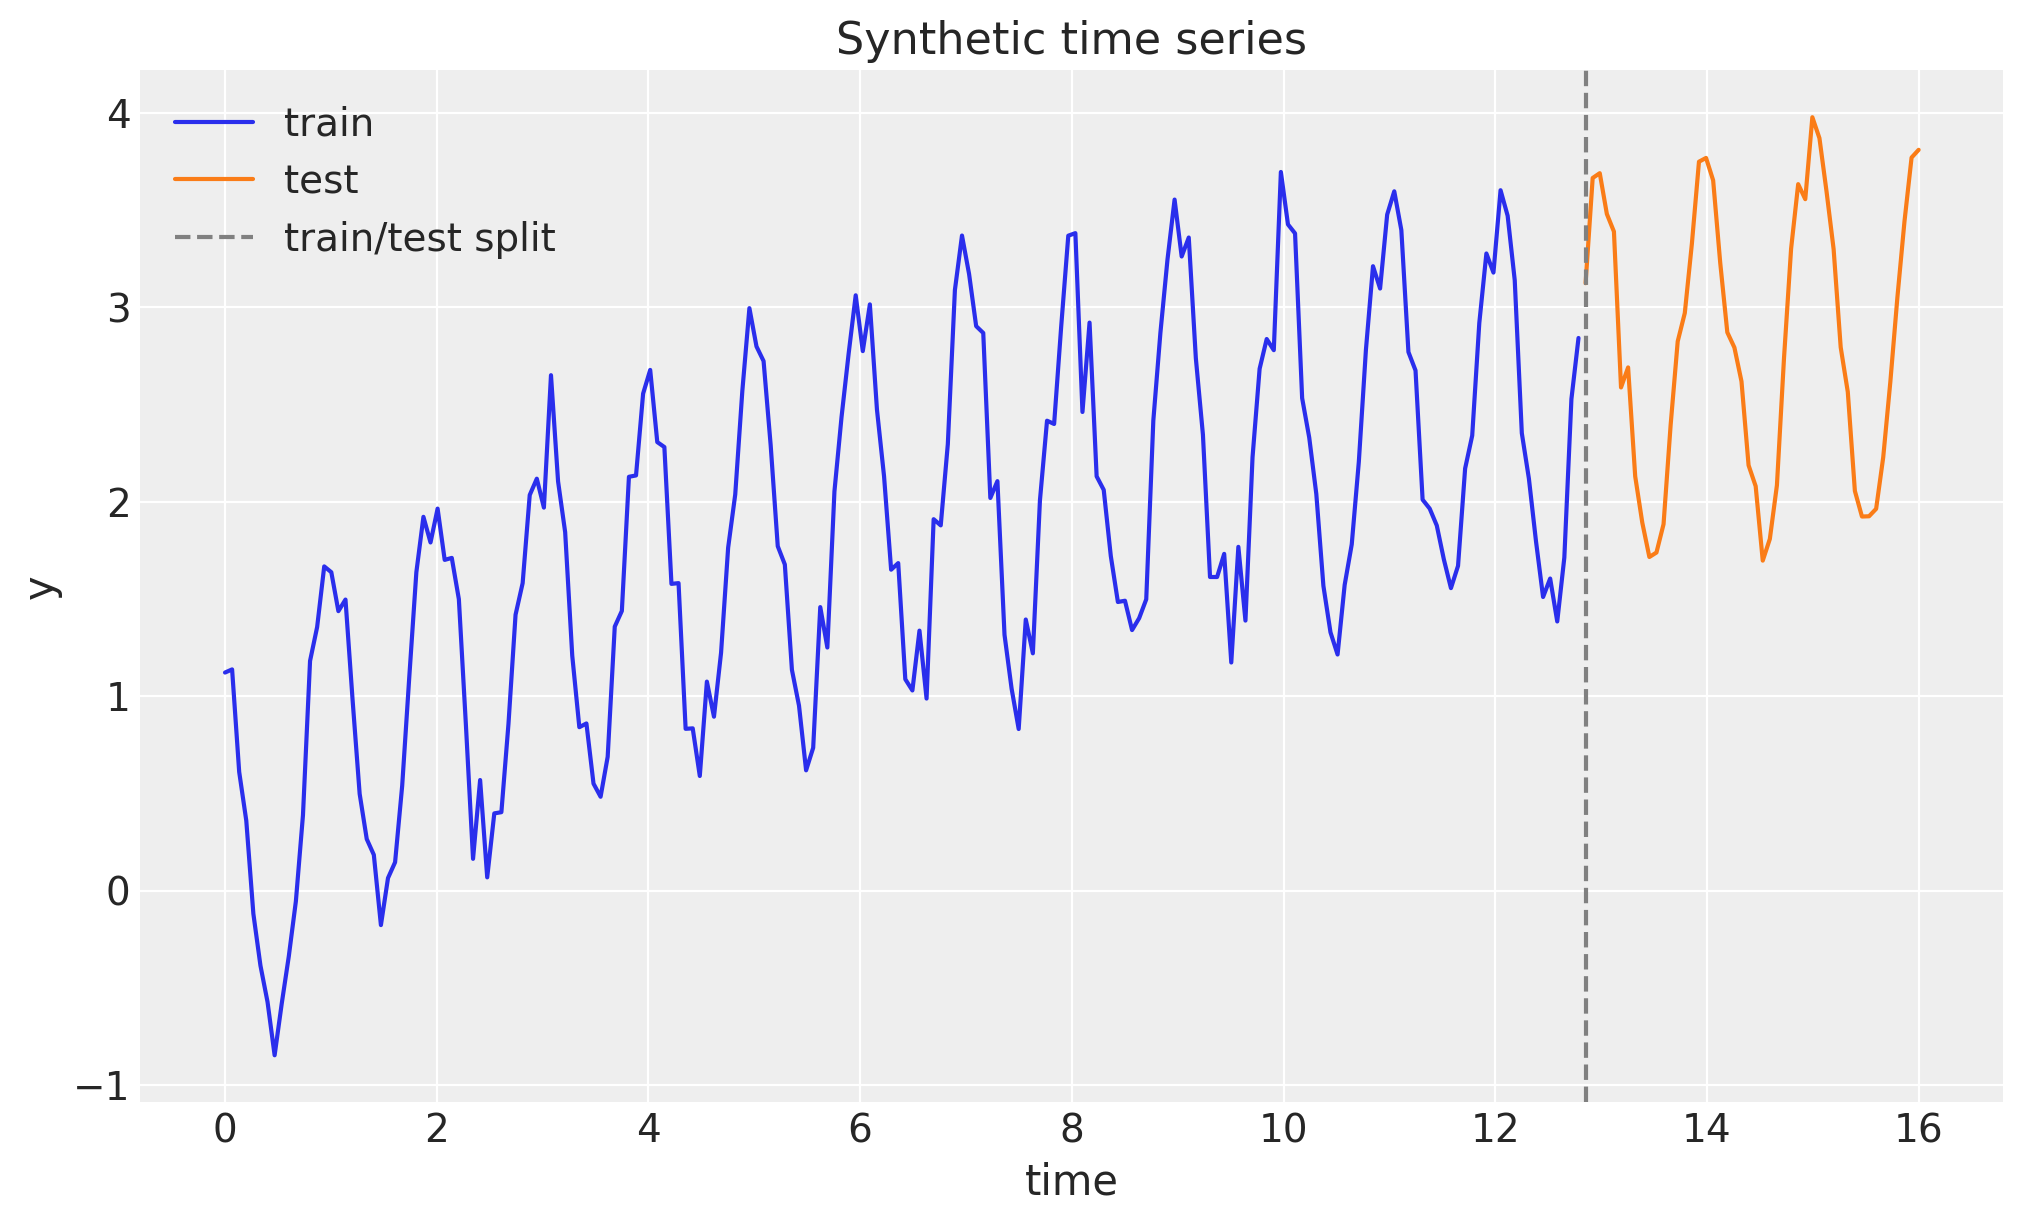

In [3]:
fig, ax = plt.subplots()
ax.plot(t_train, y_train, color="C0", label="train")
ax.plot(t_test, y_test, color="C1", label="test")
ax.axvline(float(t_test[0]), color="gray", linestyle="--", label="train/test split")
ax.legend(loc="upper left")
ax.set(title="Synthetic time series", xlabel="time", ylabel="y")
plt.show()

## A short detour on `scan`

Exponential smoothing is defined by a recursion: each state depends on
the previous one. In JAX we express such recursions with
[`jax.lax.scan`](https://docs.jax.dev/en/latest/_autosummary/jax.lax.scan.html)
rather than a Python `for` loop, because `scan` compiles to a single
efficient, differentiable operation. Conceptually `scan` is equivalent
to the following pure-Python function (from the JAX documentation):

``` python
def scan(f, init, xs, length=None):
    if xs is None:
        xs = [None] * length
    carry = init
    ys = []
    for x in xs:
        carry, y = f(carry, x)
        ys.append(y)
    return carry, np.stack(ys)
```

It threads a *carry* (the running state) through a step function `f`,
and stacks the per-step outputs. As a warm-up, we use `scan` to compute
the geometric damping sum
$\varphi_h = \varphi + \varphi^2 + \cdots + \varphi^h$ that appears in
the damped-trend forecast formula below. The carry holds the running sum
and the current power of $\varphi$.

In [4]:
def damping_sum(phi, h):
    def step(carry, _):
        running_sum, power = carry
        power = power * phi
        running_sum = running_sum + power
        return (running_sum, power), running_sum

    (total, _), partial_sums = jax.lax.scan(step, (0.0, 1.0), xs=None, length=h)
    return total, partial_sums


phi_example = 0.8
total, partial_sums = damping_sum(phi_example, 5)
closed_form = sum(phi_example**i for i in range(1, 6))
print(f"scan result:  {float(total):.5f}")
print(f"closed form:  {closed_form:.5f}")
print(f"partial sums: {np.asarray(partial_sums).round(5)}")

scan result:  2.68928
closed form:  2.68928
partial sums: [0.8     1.44    1.952   2.3616  2.68928]

## From component form to state space form

The classical **damped Holt-Winters** method with additive seasonality
of period $m$ is a set of recursive updates for the level $\ell_t$, the
trend $b_t$, and the seasonal component $s_t$, together with an $h$-step
forecast,

$$\begin{align}
\hat{y}_{t+h \mid t} &= \ell_t + \varphi_h \, b_t + s_{t + h - m(k+1)}, \\
\ell_t &= \alpha (y_t - s_{t-m}) + (1 - \alpha)(\ell_{t-1} + \varphi \, b_{t-1}), \\
b_t &= \beta^{*} (\ell_t - \ell_{t-1}) + (1 - \beta^{*}) \varphi \, b_{t-1}, \\
s_t &= \gamma (y_t - \ell_{t-1} - \varphi \, b_{t-1}) + (1 - \gamma) s_{t-m},
\end{align}$$

where $\alpha, \beta^{*}, \gamma \in (0, 1)$ are smoothing parameters,
$\varphi \in (0, 1)$ is the damping factor,
$\varphi_h = \varphi + \varphi^2 + \cdots + \varphi^h$, and
$k = \lfloor (h-1)/m \rfloor$.

The **innovations state space form** (SSOE) rewrites this as a
generative model driven by a *single* error term $\varepsilon_t$ shared
across all equations,

$$\begin{align}
y_t &= \underbrace{\ell_{t-1} + \varphi \, b_{t-1} + s_{t-m}}_{\mu_t} + \varepsilon_t, \qquad \varepsilon_t \sim \text{Normal}(0, \sigma), \\
\ell_t &= \ell_{t-1} + \varphi \, b_{t-1} + \alpha \, \varepsilon_t, \\
b_t &= \varphi \, b_{t-1} + \beta \, \varepsilon_t, \\
s_t &= s_{t-m} + \gamma \, \varepsilon_t,
\end{align}$$

with the coefficient map $\beta = \beta^{*} \alpha$ and
$\gamma = \gamma^{*} (1 - \alpha)$. The two forms are mathematically
equivalent, but the SSOE form is the one we want for probabilistic
forecasting. In sample, the innovation is exactly the one-step-ahead
forecast error $\varepsilon_t = y_t - \mu_t$, so the whole state
trajectory is a deterministic function of the observed data and the
parameters. Out of sample there is no data, so $\varepsilon_t$ is
*sampled* and fed back into the level, trend, and seasonal updates.
Because a single innovation drives every component, the forecast
uncertainty compounds and the prediction interval widens with the
horizon, which is the behavior we expect from a genuine stochastic
process.

## The model

We implement the SSOE model as a functional `numpyro_forecast` model
body. A model body receives the per-call
[`Horizon`](https://juanitorduz.github.io/numpyro_forecast/reference/functional.Horizon.html)
(which exposes the observed data `h.data`, the number of in-sample steps
`h.t_obs`, and the forecast length `h.future`) plus the covariates, and
registers its sample sites. Wrapping it with `forecasting_model` turns
it into the standard `(covariates, data=None)` callable that
`HMCForecaster` and `Predictive` consume.

The body does two things with `scan`, neither of which contains a
NumPyro sample site (so plain `jax.lax.scan` is all we need, and
reverse-mode automatic differentiation works out of the box):

1.  **In sample.** A deterministic filter consumes the observed series
    to produce the one-step-ahead means $\mu_t$; the whole in-sample
    likelihood is then a single `Normal` observation site `"obs"`. We
    also expose $\mu_t$ as a deterministic site `"mu"` for the in-sample
    fit plot.
2.  **Out of sample.** When `h.future > 0` we draw the horizon
    innovations from the prior at a separate `"eps_future"` site, roll
    the state forward feeding those innovations back, and expose the
    result as the deterministic `"forecast"` site that the forecaster
    reads. Because `"eps_future"` does not exist while training,
    `Predictive` draws it from the prior at forecast time, exactly like
    the built-in `_future` sites.

The priors follow the source post: $\text{Beta}(5, 5)$ on the level,
trend, and seasonal smoothing parameters (flat enough near the
boundaries to avoid a funnel-shaped posterior), $\text{Beta}(2, 5)$ on
the damping factor (favoring some damping), a tight
$\text{HalfNormal}(0.5)$ on the noise, and weakly informative priors on
the initial states.

In [5]:
N_SEASONS = 15


def exponential_smoothing_ssm(h: Horizon, covariates: Array) -> None:
    if h.data is None:
        msg = "the exponential smoothing model requires observed data"
        raise ValueError(msg)
    y_obs = h.data[..., 0]

    # Smoothing parameters, damping, initial states, and observation noise.
    level_smoothing = numpyro.sample("level_smoothing", dist.Beta(5, 5))
    level_init = numpyro.sample("level_init", dist.Normal(y_obs[0], 1))
    trend_smoothing = numpyro.sample("trend_smoothing", dist.Beta(5, 5))
    trend_init = numpyro.sample("trend_init", dist.Normal(0, 0.1))
    seasonality_smoothing = numpyro.sample("seasonality_smoothing", dist.Beta(5, 5))
    phi = numpyro.sample("phi", dist.Beta(2, 5))
    with numpyro.plate("n_seasons", N_SEASONS):
        seasonality_init = numpyro.sample("seasonality_init", dist.Normal(0, 1))
    noise = numpyro.sample("noise", dist.HalfNormal(0.5))

    # Component form to SSOE coefficient map.
    beta = trend_smoothing * level_smoothing
    gamma = seasonality_smoothing * (1 - level_smoothing)

    def transition(carry, y_t):
        level, trend, seasonality = carry
        mu = level + phi * trend + seasonality[0]
        error = y_t - mu  # in-sample innovation = one-step-ahead forecast error
        level = level + phi * trend + level_smoothing * error
        trend = phi * trend + beta * error
        new_season = seasonality[0] + gamma * error
        seasonality = jnp.concatenate([seasonality[1:], new_season[None]])
        return (level, trend, seasonality), mu

    init_state = (level_init, trend_init, seasonality_init)
    final_state, mu = jax.lax.scan(transition, init_state, y_obs)

    numpyro.deterministic("mu", mu[:, None])
    numpyro.sample("obs", dist.Normal(mu[:, None], noise), obs=h.data)

    if h.future > 0:
        eps_future = numpyro.sample(
            "eps_future", dist.Normal(0, noise).expand([h.future]).to_event(1)
        )

        def forecast_step(carry, eps):
            level, trend, seasonality = carry
            mu = level + phi * trend + seasonality[0]
            y_hat = mu + eps  # sampled innovation is fed back into the state
            level = level + phi * trend + level_smoothing * eps
            trend = phi * trend + beta * eps
            new_season = seasonality[0] + gamma * eps
            seasonality = jnp.concatenate([seasonality[1:], new_season[None]])
            return (level, trend, seasonality), y_hat

        _, y_future = jax.lax.scan(forecast_step, final_state, eps_future)
        numpyro.deterministic("forecast", y_future[:, None])


model = forecasting_model(exponential_smoothing_ssm)

## Priors

Before fitting, it is worth looking at the priors on the bounded
parameters. The $\text{Beta}(5, 5)$ prior on the smoothing parameters is
symmetric and concentrated away from $0$ and $1$, which keeps the
sampler away from the boundary regions where the posterior geometry
degenerates. The $\text{Beta}(2, 5)$ prior on the damping factor
$\varphi$ puts more mass below $0.5$, encoding a mild preference for
damped (non-explosive) trends.

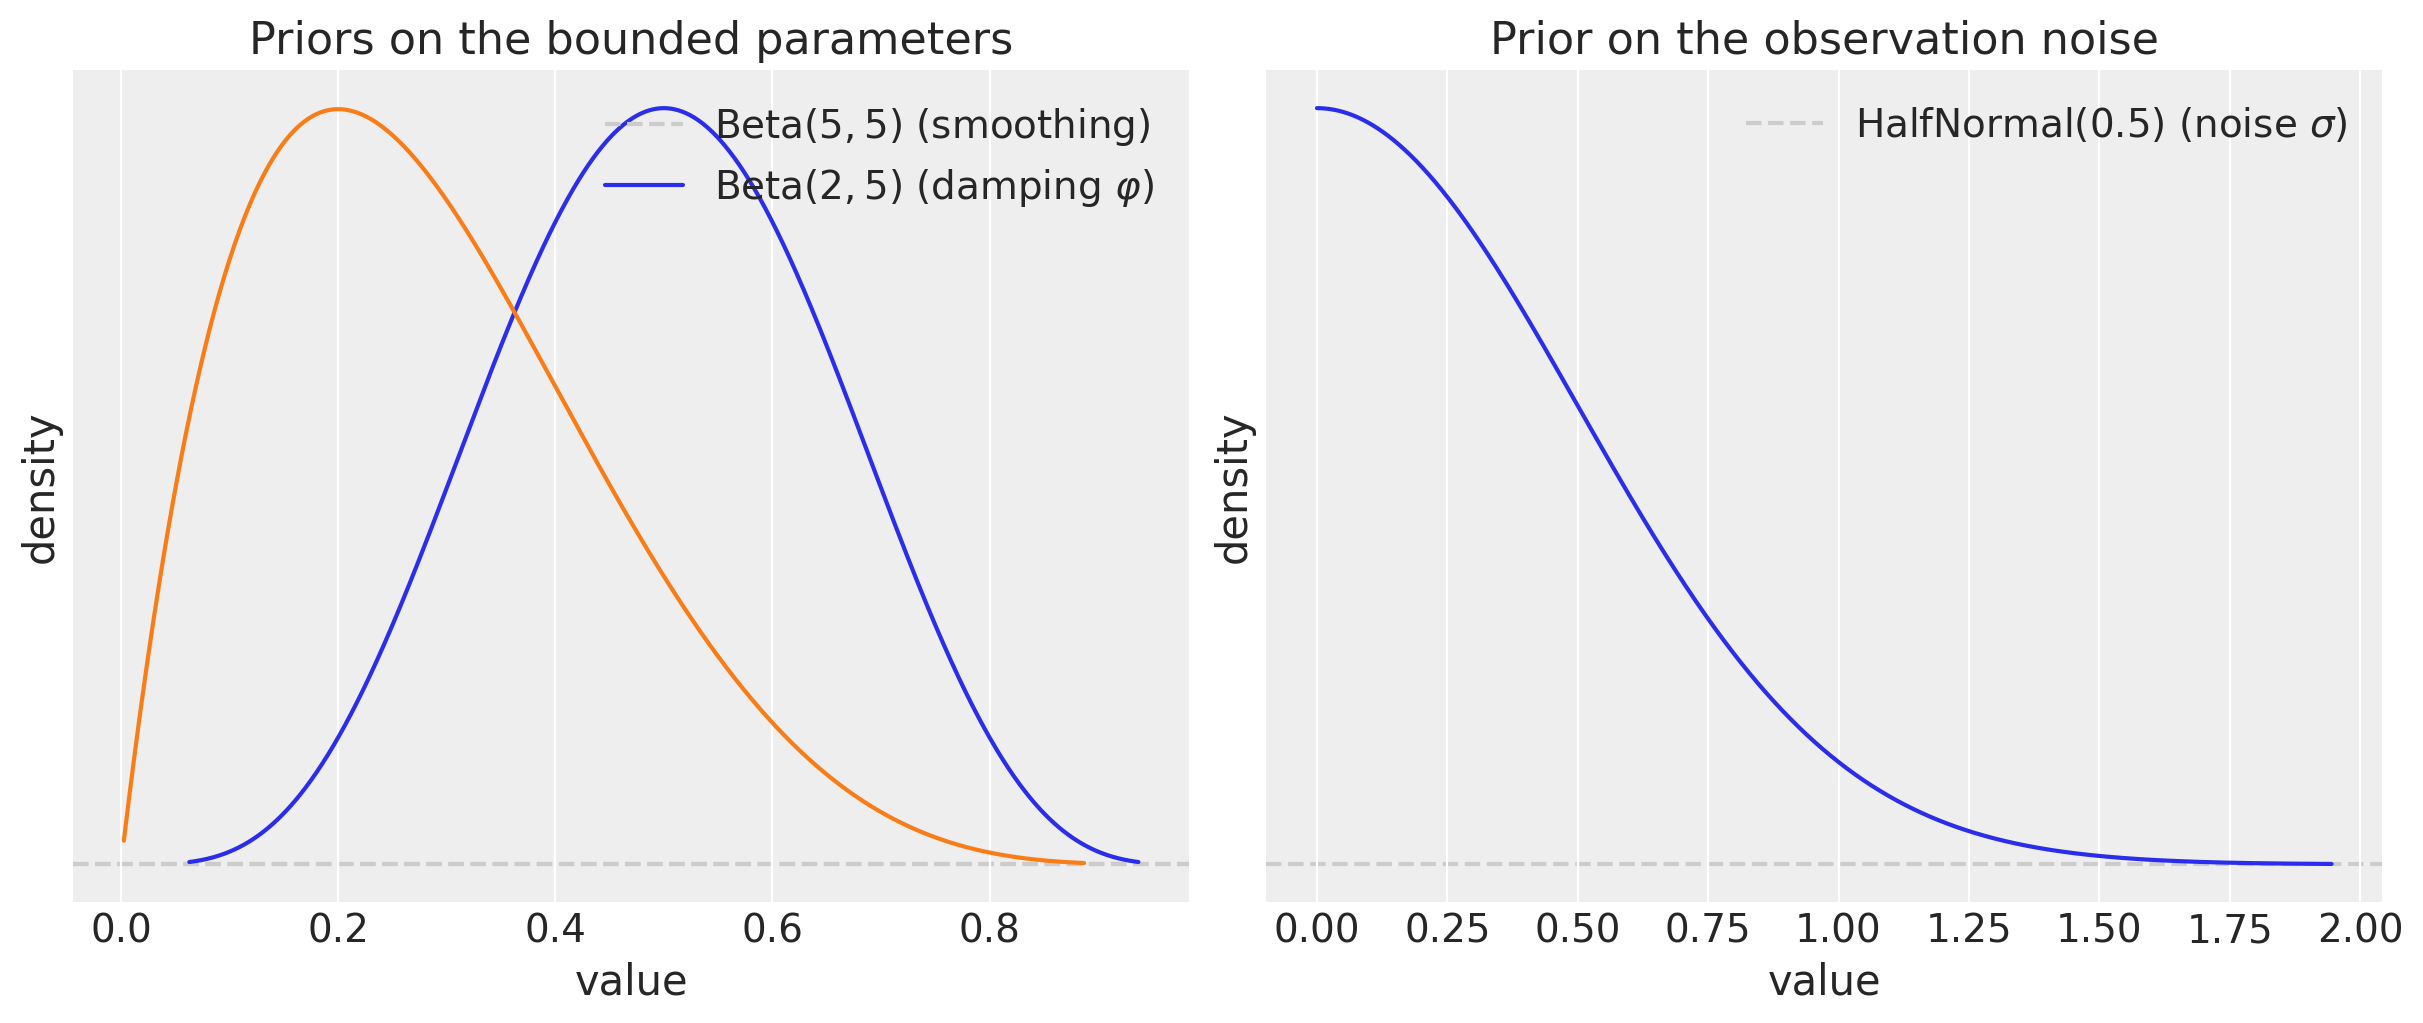

In [6]:
fig, (ax_smoothing, ax_noise) = plt.subplots(
    nrows=1, ncols=2, figsize=(12, 5), layout="constrained"
)
pz.Beta(5, 5).plot_pdf(ax=ax_smoothing, legend=False)
pz.Beta(2, 5).plot_pdf(ax=ax_smoothing, legend=False)
ax_smoothing.legend(
    [r"$\text{Beta}(5, 5)$ (smoothing)", r"$\text{Beta}(2, 5)$ (damping $\varphi$)"],
    loc="upper right",
)
ax_smoothing.set(title="Priors on the bounded parameters", xlabel="value", ylabel="density")

pz.HalfNormal(0.5).plot_pdf(ax=ax_noise, legend=False)
ax_noise.legend([r"$\text{HalfNormal}(0.5)$ (noise $\sigma$)"], loc="upper right")
ax_noise.set(title="Prior on the observation noise", xlabel="value", ylabel="density")
plt.show()

## Inference

We fit the model with the NUTS sampler through `HMCForecaster`, running
$4$ chains of $2{,}000$ warmup and $2{,}000$ sampling steps each.
`HMCForecaster` takes the model, the in-sample data, and the covariates
over the training window, and runs the No-U-Turn Sampler under the hood.

In [7]:
rng_key, rng_subkey = random.split(rng_key)
forecaster = HMCForecaster(
    rng_subkey,
    model,
    train_data,
    covariates_train,
    num_warmup=2_000,
    num_samples=2_000,
    num_chains=4,
)

## Diagnostics

`HMCForecaster` stores the posterior draws with the chains flattened
together. NumPyro flattens the chains in order, so we can recover the
`(chain, draw)` structure with a plain reshape and hand it to ArviZ for
the standard convergence diagnostics.

In [8]:
num_chains = 4
posterior = {
    name: np.asarray(value).reshape(num_chains, -1, *value.shape[1:])
    for name, value in forecaster.posterior_samples.items()
}
idata = az.from_dict({"posterior": posterior})

scalar_vars = [
    "level_smoothing",
    "trend_smoothing",
    "seasonality_smoothing",
    "phi",
    "noise",
    "level_init",
    "trend_init",
]
rhat = az.rhat(idata, var_names=scalar_vars)
ess_bulk = az.ess(idata, var_names=scalar_vars)
ess_tail = az.ess(idata, var_names=scalar_vars, method="tail")
diagnostics = pd.DataFrame(
    {
        "r_hat": [float(rhat[name].item()) for name in scalar_vars],
        "ess_bulk": [float(ess_bulk[name].item()) for name in scalar_vars],
        "ess_tail": [float(ess_tail[name].item()) for name in scalar_vars],
    },
    index=scalar_vars,
)
diagnostics.round({"r_hat": 3, "ess_bulk": 0, "ess_tail": 0})

The $\hat{R}$ values are close to $1$ and the effective sample sizes are
healthy, which indicates that the chains have mixed well. This is the
payoff of the state space parameterization together with the tuned
priors: the posterior geometry is well behaved and the sampler explores
it without trouble. The trace plots below confirm the good mixing.

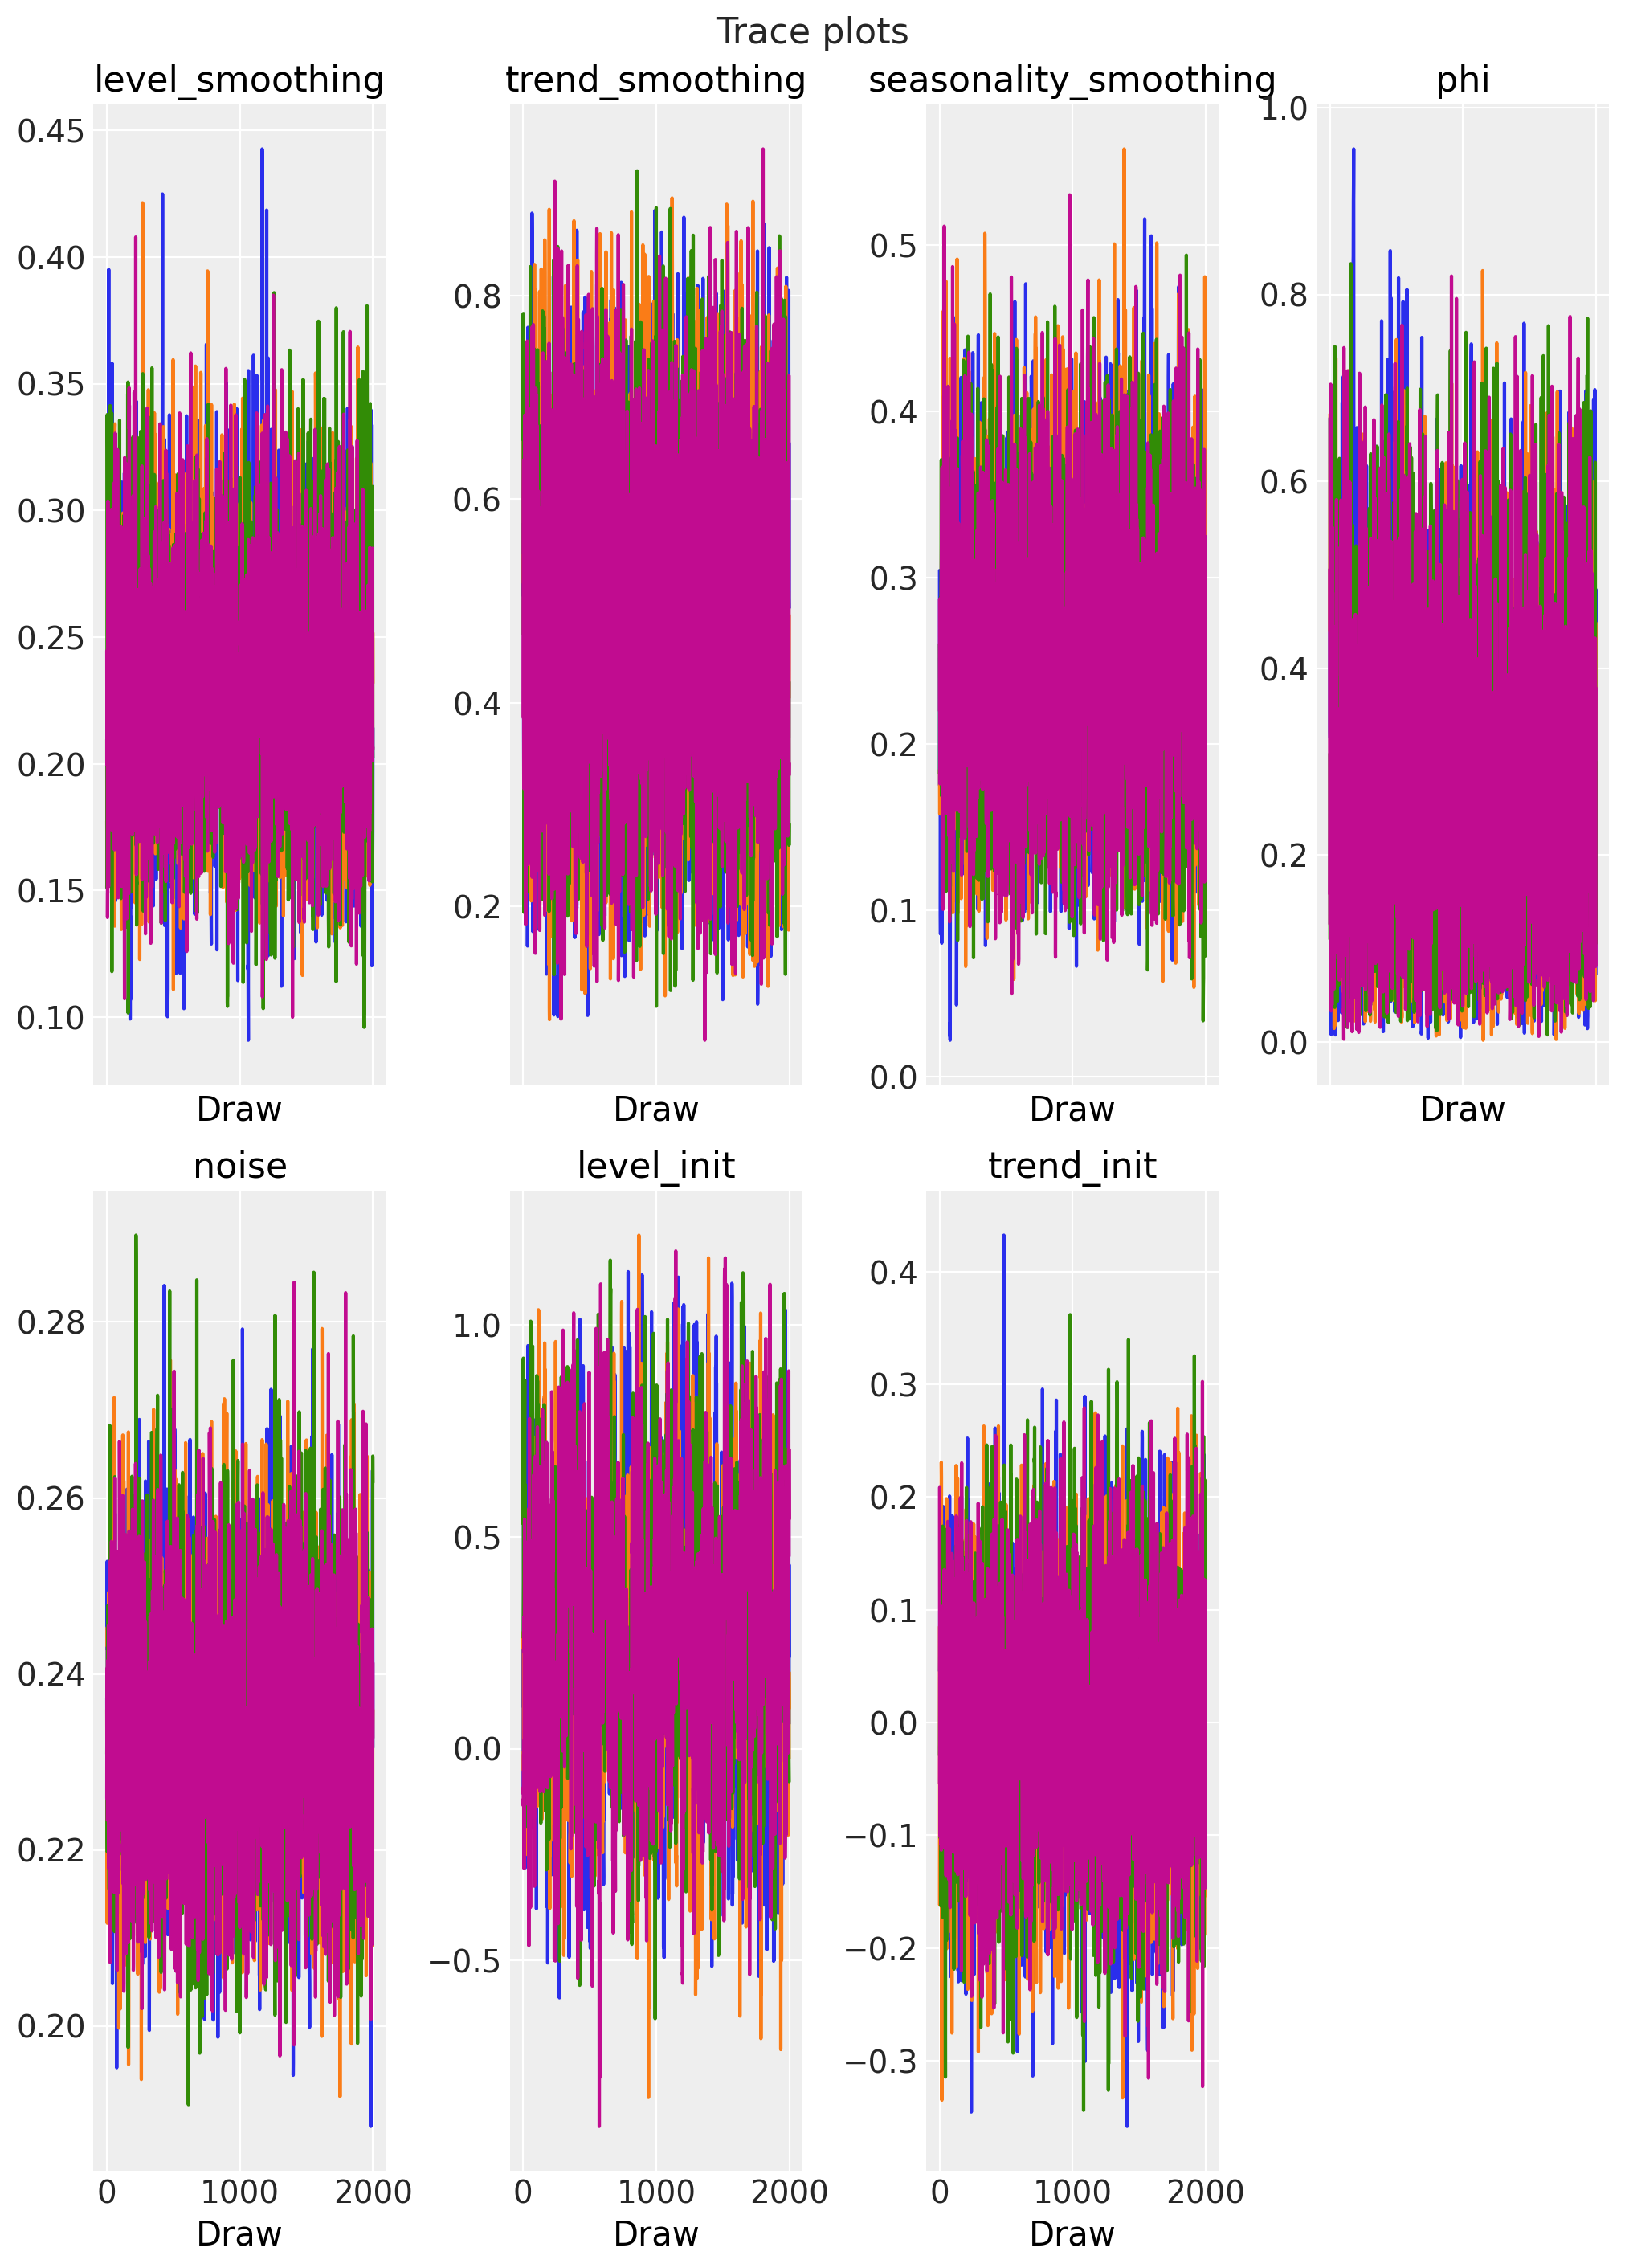

In [9]:
pc_trace = az.plot_trace(idata, var_names=scalar_vars, figure_kwargs={"figsize": (10, 14)})
pc_trace.viz["figure"].item().suptitle("Trace plots", fontsize=16)
plt.show()

## Forecast

We now generate the forecast over the test horizon. Calling the fitted
forecaster with the full-horizon covariates returns forecast samples of
shape `(sample, future, obs)`: for each posterior draw the model replays
the in-sample filter, then rolls the state forward while sampling fresh
innovations. For the in-sample fit we draw the one-step-ahead posterior
predictive (the fitted mean plus observation noise).

In [10]:
num_forecast_samples = 2_000

rng_key, rng_subkey = random.split(rng_key)
forecast_samples = forecaster(
    rng_subkey, train_data, covariates_full, num_samples=num_forecast_samples
)

# In-sample one-step-ahead posterior predictive: fitted mean "mu" plus observation noise.
rng_key, rng_subkey = random.split(rng_key)
mu_in_sample = Predictive(
    model, posterior_samples=forecaster.posterior_samples, return_sites=["mu"]
)(rng_subkey, covariates_train, train_data)["mu"]
noise_samples = forecaster.posterior_samples["noise"][:, None, None]
rng_key, rng_subkey = random.split(rng_key)
in_sample_pp = mu_in_sample + noise_samples * random.normal(rng_subkey, mu_in_sample.shape)

print(f"in-sample posterior predictive: {in_sample_pp.shape}")
print(f"forecast samples: {forecast_samples.shape}")

in-sample posterior predictive: (8000, 192, 1)
forecast samples: (2000, 48, 1)

We visualize both the in-sample fit and the forecast with `az.plot_lm`,
showing the $50\%$ and $94\%$ HDI bands. The forecast band (in orange)
clearly fans out as the horizon grows: this is the calibrated
uncertainty that the innovations state space form provides.

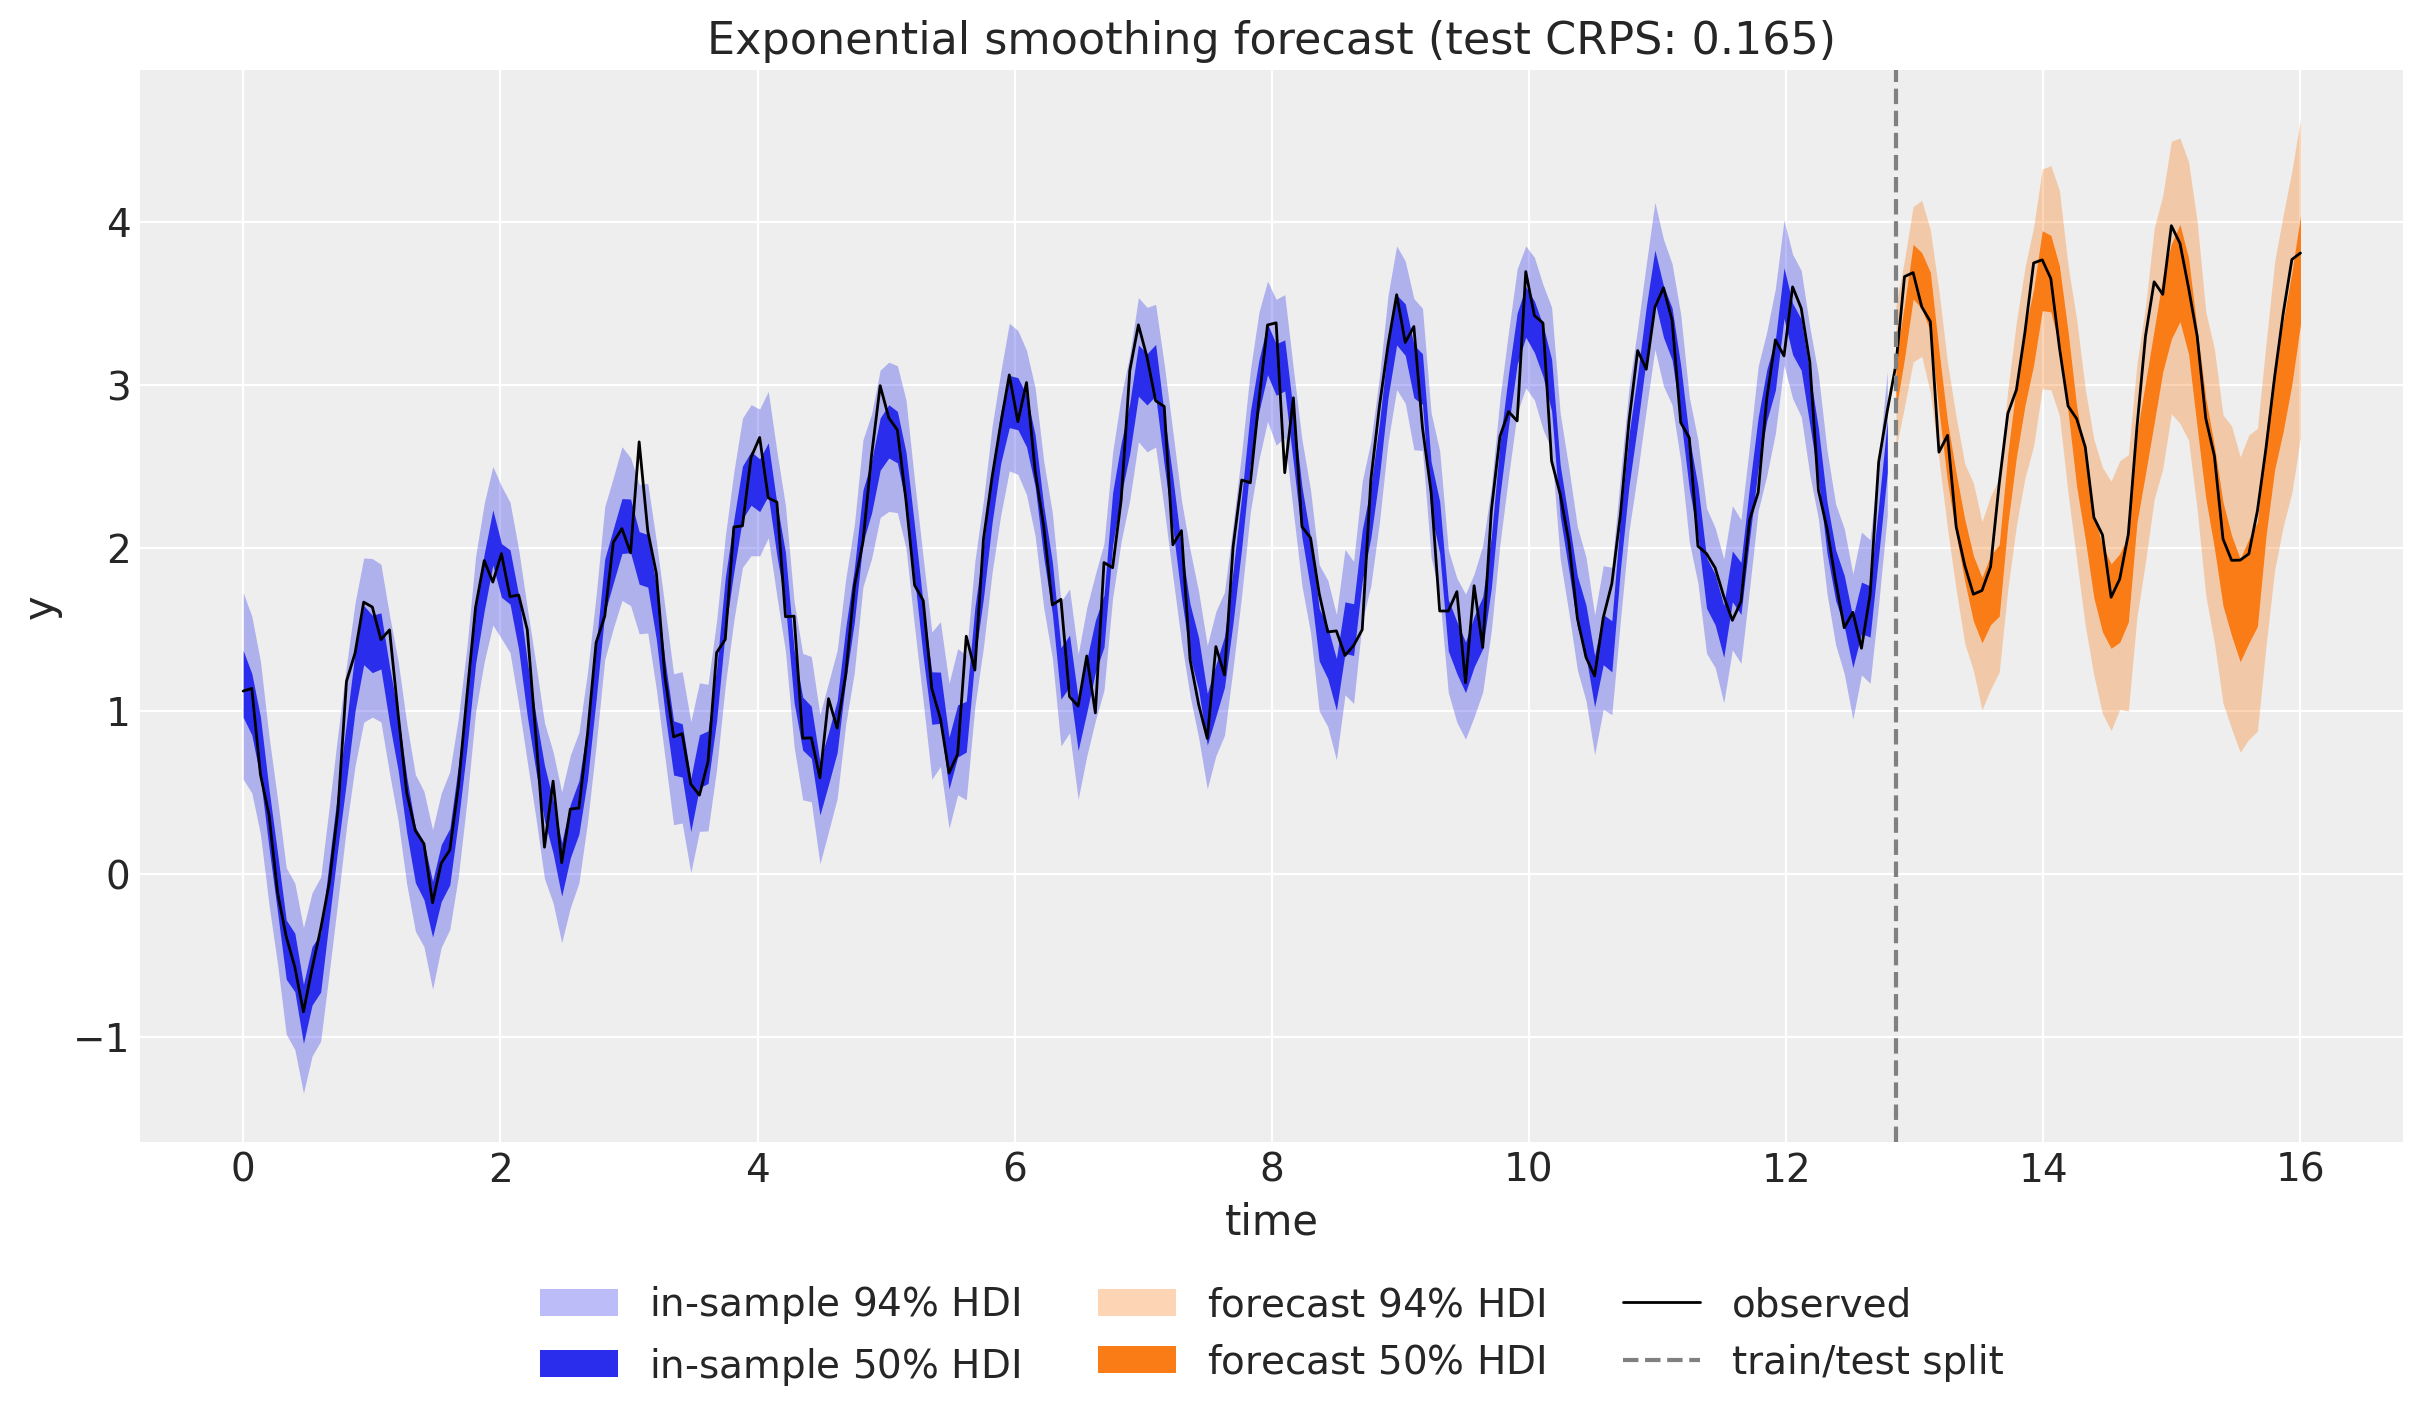

In [11]:
crps = eval_crps(forecast_samples, test_data)

idata_in_sample = az.from_dict(
    {
        "posterior_predictive": {"obs": np.asarray(in_sample_pp[..., 0])[None]},
        "observed_data": {"obs": np.asarray(y_train)},
        "constant_data": {"time": np.asarray(t_train)},
    },
    coords={"t": np.asarray(t_train)},
    dims={"obs": ["t"], "time": ["t"]},
)
idata_forecast = az.from_dict(
    {
        "posterior_predictive": {"obs": np.asarray(forecast_samples[..., 0])[None]},
        "observed_data": {"obs": np.asarray(y_test)},
        "constant_data": {"time": np.asarray(t_test)},
    },
    coords={"t": np.asarray(t_test)},
    dims={"obs": ["t"], "time": ["t"]},
)

pc = az.plot_lm(
    idata_in_sample,
    y="obs",
    x="time",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={"ci_band": {"color": "C0"}, "observed_scatter": False, "pe_line": False},
    figure_kwargs={"figsize": (12, 7)},
)
in_sample_bands = pc.viz["ci_band"]["time"]
band_in_94 = in_sample_bands.sel(prob=0.94).item()
band_in_50 = in_sample_bands.sel(prob=0.5).item()

az.plot_lm(
    idata_forecast,
    y="obs",
    x="time",
    plot_collection=pc,
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={"ci_band": {"color": "C1"}, "observed_scatter": False, "pe_line": False},
)
forecast_bands = pc.viz["ci_band"]["time"]
band_fc_94 = forecast_bands.sel(prob=0.94).item()
band_fc_50 = forecast_bands.sel(prob=0.5).item()

ax = pc.viz["figure"].item().axes[0]
band_in_94.set_label(r"in-sample $94\%$ HDI")
band_in_50.set_label(r"in-sample $50\%$ HDI")
band_fc_94.set_label(r"forecast $94\%$ HDI")
band_fc_50.set_label(r"forecast $50\%$ HDI")
(observed_line,) = ax.plot(np.asarray(t), np.asarray(y), color="black", lw=1, label="observed")
split_line = ax.axvline(float(t_test[0]), color="gray", linestyle="--", label="train/test split")
ax.legend(
    handles=[band_in_94, band_in_50, band_fc_94, band_fc_50, observed_line, split_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
ax.set(title=f"Exponential smoothing forecast (test CRPS: {crps:.3f})", xlabel="time", ylabel="y")
plt.show()

## Evaluation

Finally, we score the forecast against the held-out test set with the
package’s evaluation metrics: mean absolute error and root mean squared
error (point-forecast accuracy), the continuous ranked probability score
(a proper score for the whole predictive distribution), and the
empirical coverage of the central $90\%$ interval (calibration).

In [12]:
metrics = {
    "MAE": eval_mae(forecast_samples, test_data),
    "RMSE": eval_rmse(forecast_samples, test_data),
    "CRPS": eval_crps(forecast_samples, test_data),
    "coverage (90%)": eval_coverage(forecast_samples, test_data),
}
for name, value in metrics.items():
    print(f"{name:>16}: {value:.4f}")

             MAE: 0.2432
            RMSE: 0.2797
            CRPS: 0.1648
  coverage (90%): 0.9583

The coverage of the central $90\%$ interval sits close to its nominal
level, confirming that the forecast is well calibrated. For a systematic
assessment over multiple origins you would reach for
`numpyro_forecast.backtest`, which refits the model on a moving window;
we omit it here because it retrains the full sampler for every window.

## References

- Hyndman, R. J., & Athanasopoulos, G. (2021). [*Forecasting: Principles
  and Practice*](https://otexts.com/fpp3/), 3rd edition. Chapters on
  exponential smoothing and ETS models.
- Hyndman, R. J., Koehler, A. B., Ord, J. K., & Snyder, R. D. (2008).
  *Forecasting with Exponential Smoothing: The State Space Approach*.
  Springer.
- Orduz, J. [*Exponential Smoothing with NumPyro: State Space
  Form*](https://juanitorduz.github.io/exponential_smoothing_numpyro_ssm/).
- Orduz, J. [*Notes on Exponential Smoothing with
  NumPyro*](https://juanitorduz.github.io/exponential_smoothing_numpyro/).